Siamo molto bravi a programmare


In [62]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

Poi abbiamo importato

In [63]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

print(artists.head())


     id_author           name gender  birth_date birth_place nationality  \
0  ART82291002       99 posse      M         NaN         NaN         NaN   
1  ART53496045  achille lauro      M  1990-07-11      Verona      Italia   
2  ART18853907           alfa      M         NaN         NaN         NaN   
3  ART64265460      anna pepe      F         NaN         NaN         NaN   
4  ART75741740    articolo 31      M         NaN         NaN         NaN   

                            description active_start  active_end province  \
0              gruppo musicale italiano   1991-01-01         NaN      NaN   
1  cantautore e rapper italiano (1990-)   2012-01-01         NaN   Verona   
2                                   NaN          NaN         NaN      NaN   
3                                   NaN          NaN         NaN      NaN   
4      gruppo musicale hip hop italiano   1990-01-01         NaN      NaN   

   region country   latitude  longitude  
0     NaN     NaN        NaN        Na

In [64]:
print(tracks.head())

         id    id_artist    name_artist  \
0  TR934808  ART04205421  Rosa Chemical   
1  TR760029  ART04205421  Rosa Chemical   
2  TR916821  ART04205421  Rosa Chemical   
3  TR480968  ART04205421  Rosa Chemical   
4  TR585039  ART04205421  Rosa Chemical   

                                          full_title         title  \
0    ​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè)  ​polka 2 :-/   
1         POLKA by Rosa Chemical (Ft. Thelonious B.)         POLKA   
2  ​britney ;-) by Rosa Chemical (Ft. MamboLosco ...  ​britney ;-)   
3                  CEO by Rosa Chemical (Ft. Taxi B)           CEO   
4                LONDRA by Rosa Chemical (Ft. Rkomi)        LONDRA   

      featured_artists primary_artist language              album  \
0           Ernia, Guè  Rosa Chemical       pl   FOREVER AND EVER   
1        Thelonious B.  Rosa Chemical       en   FOREVER AND EVER   
2  MamboLosco, RADICAL  Rosa Chemical       en   FOREVER AND EVER   
3               Taxi B  Rosa Chemical       

In [65]:
artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
)

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

merged.drop(columns=["artist_active_end"], inplace=True)

print(merged.head())

#print(merged["artist_active_end"].unique())

   track_id track_id_artist track_name_artist  \
0  TR934808     ART04205421     Rosa Chemical   
1  TR760029     ART04205421     Rosa Chemical   
2  TR916821     ART04205421     Rosa Chemical   
3  TR480968     ART04205421     Rosa Chemical   
4  TR585039     ART04205421     Rosa Chemical   

                                    track_full_title   track_title  \
0    ​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè)  ​polka 2 :-/   
1         POLKA by Rosa Chemical (Ft. Thelonious B.)         POLKA   
2  ​britney ;-) by Rosa Chemical (Ft. MamboLosco ...  ​britney ;-)   
3                  CEO by Rosa Chemical (Ft. Taxi B)           CEO   
4                LONDRA by Rosa Chemical (Ft. Rkomi)        LONDRA   

  track_featured_artists track_primary_artist track_language  \
0             Ernia, Guè        Rosa Chemical             pl   
1          Thelonious B.        Rosa Chemical             en   
2    MamboLosco, RADICAL        Rosa Chemical             en   
3                 Taxi B    

In [66]:
print('Numero canzoni:', len(merged))
print('Numero canzoni unique:', len(merged.track_id.unique()))

# Drop duplicate track_ids, keeping the first occurrence
merged = merged.drop_duplicates(subset=['track_id'], keep='first')

print('Numero canzoni unique (trimmed):', len(merged.track_id.unique()))
print('Numero artisti:', len(merged.artist_id_author.unique()))

Numero canzoni: 11166
Numero canzoni unique: 11093
Numero canzoni unique (trimmed): 11093
Numero artisti: 104


In [151]:
print(merged.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8414 entries, 0 to 11165
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   track_id                    8414 non-null   object 
 1   track_id_artist             8414 non-null   object 
 2   track_name_artist           8414 non-null   object 
 3   track_full_title            8414 non-null   object 
 4   track_title                 8414 non-null   object 
 5   track_featured_artists      2714 non-null   object 
 6   track_primary_artist        8414 non-null   object 
 7   track_language              8332 non-null   object 
 8   track_album                 7275 non-null   object 
 9   track_stats_pageviews       3777 non-null   float64
 10  track_swear_IT              8414 non-null   int64  
 11  track_swear_EN              8414 non-null   int64  
 12  track_swear_IT_words        8414 non-null   object 
 13  track_swear_EN_words        8414 non-

In [68]:
for i in merged.columns:
    n= merged[i].isnull().sum()
    print(f"{i}: {n} null")


track_id: 0 null
track_id_artist: 0 null
track_name_artist: 0 null
track_full_title: 0 null
track_title: 0 null
track_featured_artists: 7604 null
track_primary_artist: 0 null
track_language: 104 null
track_album: 1506 null
track_stats_pageviews: 6483 null
track_swear_IT: 0 null
track_swear_EN: 0 null
track_swear_IT_words: 0 null
track_swear_EN_words: 0 null
track_year: 400 null
track_month: 1192 null
track_day: 1317 null
track_n_sentences: 76 null
track_n_tokens: 76 null
track_tokens_per_sent: 76 null
track_char_per_tok: 76 null
track_lexical_density: 76 null
track_avg_token_per_clause: 76 null
track_bpm: 64 null
track_centroid: 64 null
track_rolloff: 64 null
track_flux: 64 null
track_rms: 64 null
track_zcr: 64 null
track_flatness: 64 null
track_spectral_complexity: 64 null
track_pitch: 64 null
track_loudness: 64 null
track_album_name: 78 null
track_album_release_date: 78 null
track_album_type: 78 null
track_disc_number: 78 null
track_track_number: 78 null
track_duration_ms: 78 null
tr

In [69]:
duplicated_tracks= len(merged) - len(merged.track_id.unique())
print('Numero canzoni duplicate:', duplicated_tracks)

Numero canzoni duplicate: 0


In [70]:
unique= []
for _, row in merged.iterrows():
    name_artist = str(row["track_name_artist"]).lower()
    artist_name = str(row["artist_name"]).lower()
    primary_artist = str(row["track_primary_artist"]).lower()
    triple = (name_artist, artist_name, primary_artist)

    if name_artist != artist_name or name_artist != primary_artist or artist_name != primary_artist:
        if triple not in unique:
            unique.append(triple)
print(unique)

[('guè', 'guè pequeno', 'guè'), ('chadia', 'chadia rodriguez', 'chadia'), ('’o zulù', 'o zulù', '’o zulù'), ('m¥ss keta', 'miss keta', 'm¥ss keta'), ('dargen d’amico', 'dargen d_amico', 'dargen d’amico'), ('mr.rain', 'mr. rain', 'mr.rain'), ('highsnob', 'mike24', 'highsnob'), ('anna', 'anna pepe', 'anna'), ('samuel costa', 'samuel heron', 'samuel costa'), ('joey (ita)', 'joey funboy', 'joey (ita)')]


In [71]:
merged['track_album_release_date'].head(30)


0     2021-04-09
1     2021-04-09
2     2021-04-09
3     2025-05-16
4     2020-05-28
5     2020-05-28
6     2020-05-28
7     2020-05-28
8     2023-02-09
9     2020-05-28
10    2022-06-02
11    2020-05-28
12    2020-05-28
13    2020-05-28
14    2021-04-09
15    2020-05-28
16    2020-05-28
17    2020-05-28
18    2020-05-28
19    2021-04-09
20    2021-04-09
21    2019-06-07
22    2025-05-16
23    2020-10-02
24    2020-10-02
25    2019-09-20
26    2019-03-08
27    2019-03-08
28    2019-03-08
29    2019-03-08
Name: track_album_release_date, dtype: object

In [72]:
float_cols = merged.select_dtypes(include=['float64','int64']).columns
for col in float_cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")
    mean = merged[col].mean()
    std_dev = merged[col].std()
    outliers = merged[col][merged[col].sub(mean).abs() > 5 * std_dev]
    count= len(outliers)
    print(f"{col}: {count} outliers " )

track_stats_pageviews: 28 outliers 
track_swear_IT: 79 outliers 
track_swear_EN: 77 outliers 
track_month: 0 outliers 
track_day: 0 outliers 
track_n_sentences: 18 outliers 
track_n_tokens: 17 outliers 
track_tokens_per_sent: 24 outliers 
track_char_per_tok: 81 outliers 
track_lexical_density: 57 outliers 
track_avg_token_per_clause: 27 outliers 
track_bpm: 1 outliers 
track_centroid: 1 outliers 
track_rolloff: 10 outliers 
track_flux: 5 outliers 
track_rms: 2 outliers 
track_zcr: 9 outliers 
track_flatness: 221 outliers 
track_spectral_complexity: 0 outliers 
track_pitch: 2 outliers 
track_loudness: 3 outliers 
track_disc_number: 171 outliers 
track_track_number: 11 outliers 
track_duration_ms: 25 outliers 
artist_latitude: 0 outliers 
artist_longitude: 0 outliers 


In [73]:
merged['track_year'].unique()

array(['2021.0', '2020.0', '2019.0', '2072', '2098', '2023.0', '2022.0',
       '1917', '1920', '2025.0', '2018.0', '1901', '2052', '2024.0',
       '2081', '2060', '2015.0', '1933', '1928', '2057', '2016.0', '2078',
       '2058', '1963', '2017.0', '1908', '2062', '2051', '2074', '2079',
       '1942', '1969', '2064', '2068', '1961', '2054', '1941', '1951',
       '1906', '2084', '1938', '2070', '1918', nan, '1944', '2097',
       '1903', '1924', '2089', '2095', '1962', '1934', '2075', '1921',
       '1935', '1912', '1937', '1947', '1929', '1939', '2080', '1949',
       '2076', '2093', '2085', '1967', '2100', '1911', '2053', '2014.0',
       '1900', '2090', '2063', '1930', '2012.0', '2013.0', '2073', '2083',
       '1958', '1954', '2099', '2088', '2087', '1952', '2056', '2077',
       '1957', '2067', '2065', '1922', '1936', '2082', 'nPmvFS', '2006.0',
       '2010.0', '2008.0', '2011.0', '1953', '1955', '2094', '1971',
       '2059', '2092', '2055', 'MoKKcY', '1948', '1968', '2086', '

In [74]:
merged["artist_active_start_year"] = (
    pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

In [75]:
# condizione da eliminare: col_a > 10 e col_b == "X"
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)

In [76]:
merged['track_year'].unique()

array([2021., 2020., 2019.,   nan, 2023., 2022., 2025., 2018., 2024.,
       2016., 2017., 2014., 2013., 2015., 1999., 2002., 2012., 2007.,
       1998., 2000., 1997., 2004., 2010., 2006., 2009., 2011., 2008.,
       2005., 2001., 1993., 1996., 2003., 1994., 1992., 1995.])

object


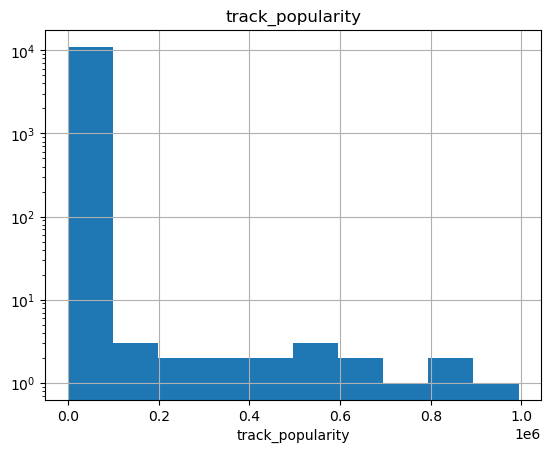

float64


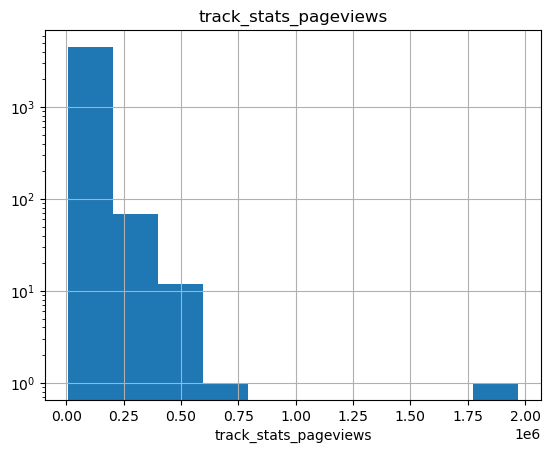

float64


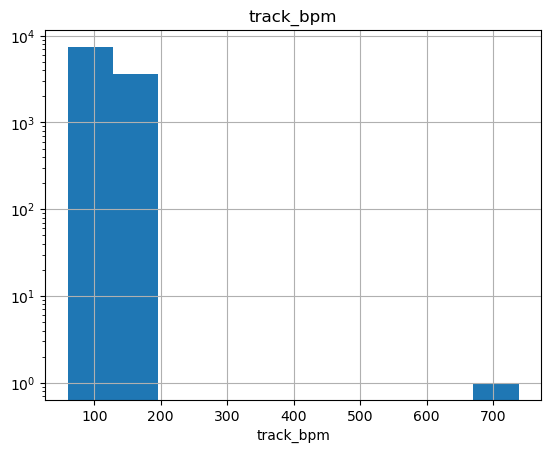

float64


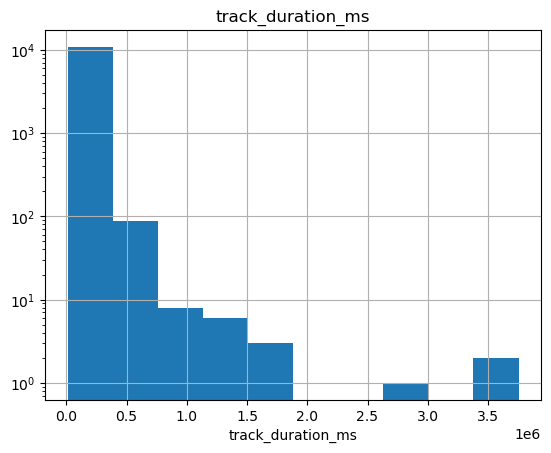

float64


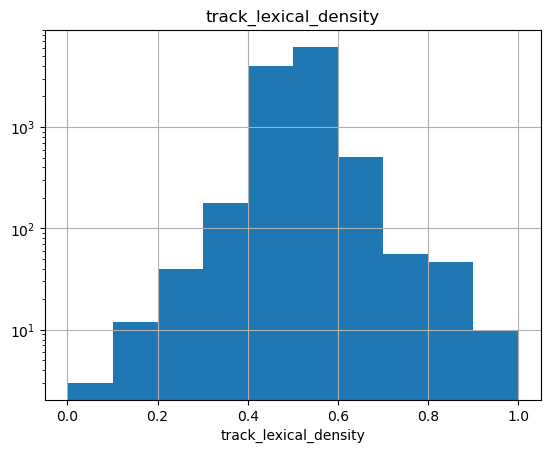

float64


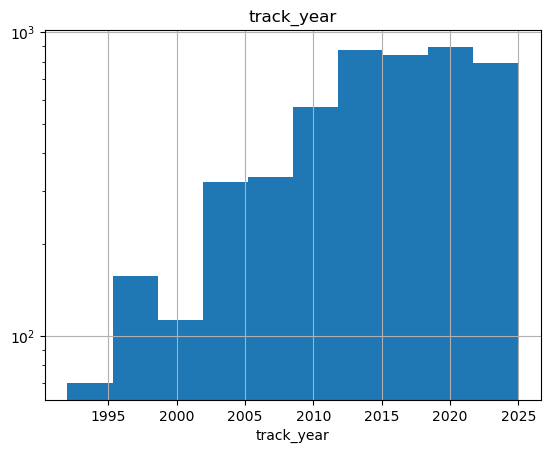

float64


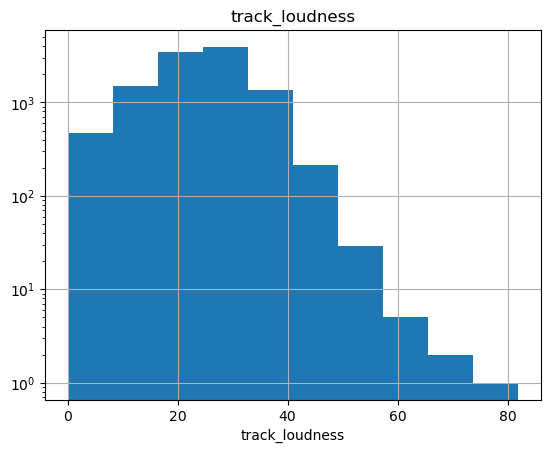

int64


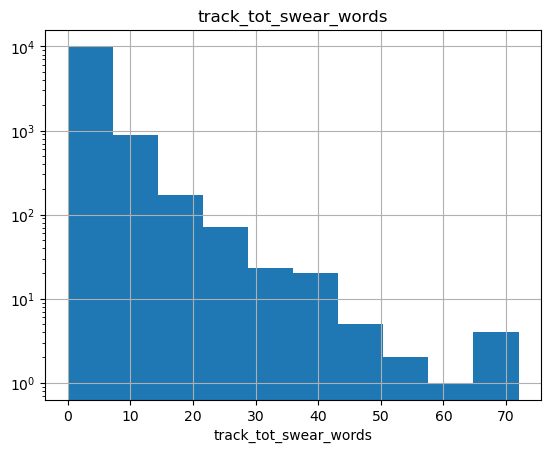

float64


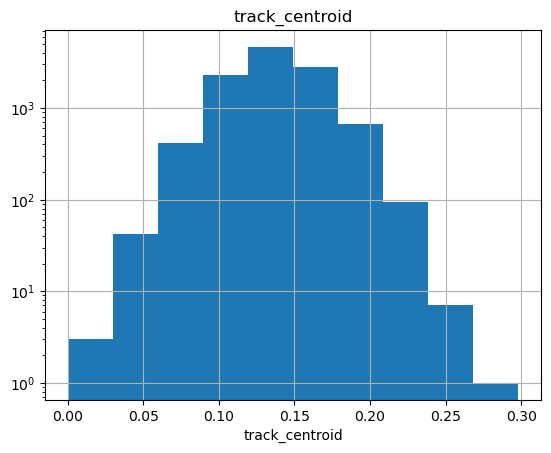

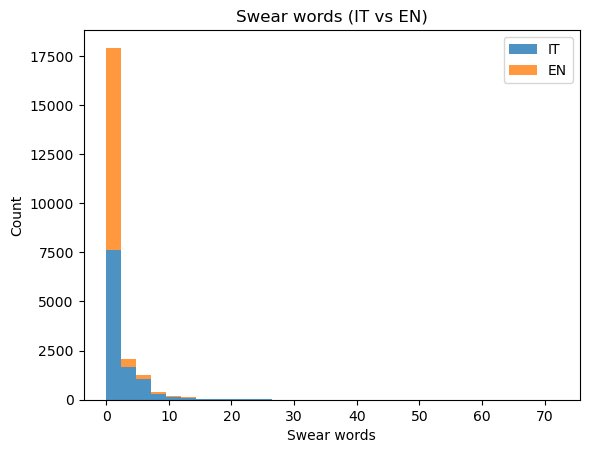

In [77]:
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]
for col_name in ["track_popularity", "track_stats_pageviews", "track_bpm", "track_duration_ms", 
                 "track_lexical_density", "track_year", "track_loudness", "track_tot_swear_words",
                 "track_centroid"]:
    print(merged[col_name].dtype)
    merged[col_name] = pd.to_numeric(merged[col_name], errors="coerce")
    plt.figure()
    merged[col_name].hist()
    plt.title(col_name)
    plt.xlabel(col_name)
    plt.yscale('log')
    plt.show()

# Istogramma cumulativo con IT/EN separati (colori diversi)
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
plt.figure()
plt.hist([swear_it, swear_en], bins=30, stacked=True, label=["IT", "EN"], alpha=0.8)
plt.title("Swear words (IT vs EN)")
plt.xlabel("Swear words")
plt.ylabel("Count")
plt.legend()
plt.show()

In [78]:
merged["track_presumed_flatness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

merged["track_artist_age"]= merged["track_year"] - merged["artist_birth_year"]

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)


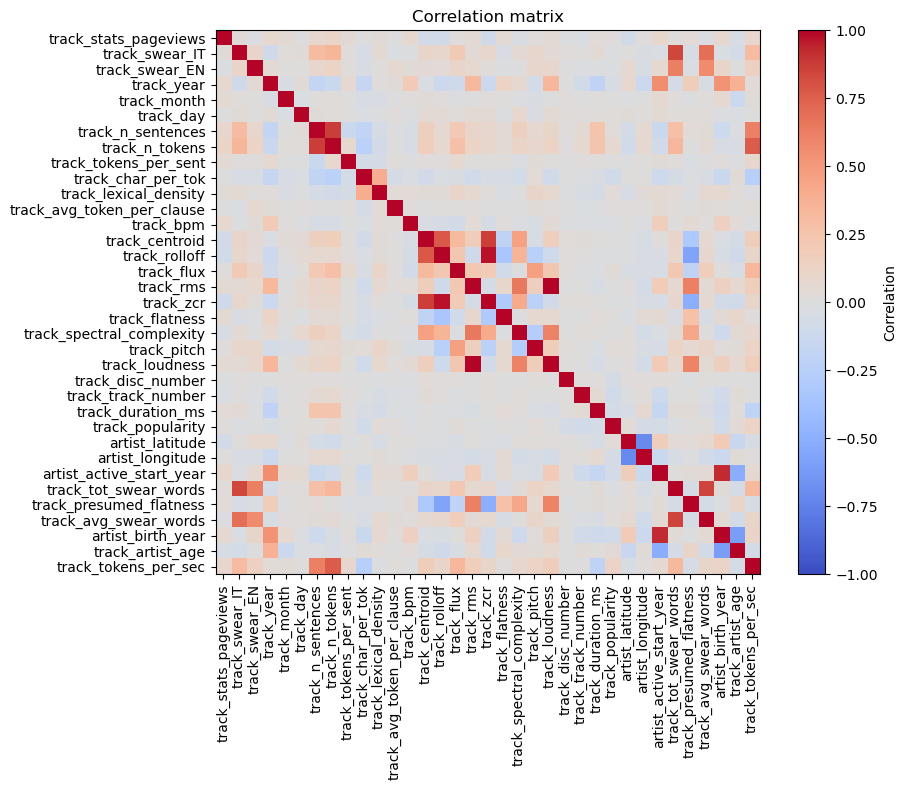

Strongly correlated pairs:
track_rms                  track_loudness               0.995550
track_rolloff              track_zcr                    0.969144
artist_active_start_year   artist_birth_year            0.927034
track_n_sentences          track_n_tokens               0.867862
track_centroid             track_zcr                    0.864460
track_tot_swear_words      track_avg_swear_words        0.850638
track_swear_IT             track_tot_swear_words        0.841941
track_centroid             track_rolloff                0.775799
track_n_tokens             track_tokens_per_sec         0.760865
track_swear_IT             track_avg_swear_words        0.692821
track_rms                  track_spectral_complexity    0.643962
track_swear_EN             track_tot_swear_words        0.624154
track_rms                  track_presumed_flatness      0.616247
track_n_sentences          track_tokens_per_sec         0.610060
track_spectral_complexity  track_loudness               0.60852

In [79]:
# Correlation heatmap for numeric columns
corr = merged.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = corr_pairs.stack().sort_values(ascending=False)
print("Strongly correlated pairs:")
print(strong_pairs[strong_pairs.abs() > 0.5])

Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

(1, 1000000.0)

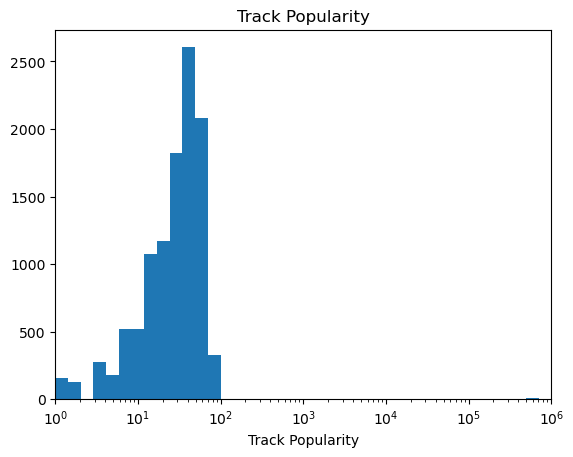

In [80]:
merged['track_popularity'] = pd.to_numeric(merged['track_popularity'], errors="coerce")
pop = merged['track_popularity'].dropna()
pop = pop[pop > 0]  # log bins need positive values

bins = np.logspace(np.log10(1), np.log10(1e6), 40)  # 40 log-width bins

plt.figure('1')
plt.hist(pop, bins=bins)
plt.xscale('log')
plt.title('Track Popularity')
plt.xlabel('Track Popularity')
plt.xlim(1, 1e6)


**Discretization strategy (justification)**
- BPM: cut at 90 and 120 BPM, common musicology thresholds for slow/medium/fast tempos.
- Popularity: use 0–30–70–100 to map to low/medium/high on a 0–100 scale.
- Duration: short < 3 min, medium 3–5 min, long > 5 min (typical radio lengths).
- Swear density: compute swear words per minute; split low/high by median to avoid skew from heavy tails.

In [81]:
# Discretize numeric variables into categorical bins
bpm = pd.to_numeric(merged["track_bpm"], errors="coerce")
pop = pd.to_numeric(merged["track_popularity"], errors="coerce")
dur = pd.to_numeric(merged["track_duration_ms"], errors="coerce")
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
swear_total = swear_it.add(swear_en, fill_value=0)

# Swear density = swear words per minute
duration_min = dur / 60000
swear_density = swear_total / duration_min
swear_density = swear_density.replace([np.inf, -np.inf], np.nan)

encoded = pd.get_dummies([])

encoded["bpm"] = pd.cut(
    bpm,
    bins=[-np.inf, 90, 120, np.inf],
    labels=["Slow", "Medium", "Fast"]
 )

encoded["popularity"] = pd.cut(
    pop,
    bins=[-np.inf, 3e1, np.inf],
    labels=["Low", "High"]
 )

encoded["duration"] = pd.cut(
    dur,
    bins=[-np.inf, 180000, 300000, np.inf],
    labels=["Short", "Medium", "Long"]
 )

median_swear_density = swear_density.median(skipna=True)
encoded["swear_density"] = pd.cut(
    swear_density,
    bins=[-np.inf, median_swear_density, np.inf],
    labels=["Low", "High"]
 )

encoded["lexical_density"] = pd.cut(
    pd.to_numeric(merged["track_lexical_density"], errors="coerce"),
    bins=[-np.inf, 0.5, np.inf],
    labels=["Low", "High"]
 )

 
encoded["loudness"] = pd.cut(
    pd.to_numeric(merged["track_loudness"], errors="coerce"),
    bins=[-np.inf, 27, 54, np.inf],
    labels=["Soft", "Medium", "Loud"]
 )

encoded["acuteness"] = pd.cut(
    pd.to_numeric(merged["track_centroid"], errors="coerce"),
    bins=[-np.inf, 0.15, np.inf],
    labels=["Low", "High"]
 )

encoded.head()

,bpm,popularity,duration,swear_density,lexical_density,loudness,acuteness
0,Fast,High,Medium,High,High,Soft,High
1,Fast,High,Medium,High,High,Soft,High
2,Fast,High,Medium,High,High,Medium,High
3,Fast,High,Short,High,High,Soft,Low
4,Medium,High,Medium,Low,Low,Soft,Low


In [82]:
print(encoded['popularity'].value_counts())


popularity
High    5795
Low     5269
Name: count, dtype: int64


In [83]:
# Build transactions with explicit col_name_value labels
transactions = encoded.apply(lambda row: [f"{col}_{row[col]}" for col in encoded.columns], axis=1).tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

df["swear_high_short"] = df["swear_density_High"] & df["duration_Short"]
df["swear_low_soft"] = df["swear_density_Low"] & df["loudness_Soft"]
df["swear_low_popular"] = df["swear_density_Low"] & df["popularity_High"]
df["lexical_low_soft"] = df["lexical_density_Low"] & df["loudness_Soft"]

df.head()

,acuteness_High,acuteness_Low,acuteness_nan,bpm_Fast,bpm_Medium,bpm_Slow,bpm_nan,duration_Long,duration_Medium,duration_Short,...,popularity_High,popularity_Low,popularity_nan,swear_density_High,swear_density_Low,swear_density_nan,swear_high_short,swear_low_soft,swear_low_popular,lexical_low_soft
0,True,False,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
1,True,False,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
2,True,False,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
3,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,True,False,False,False
4,False,True,False,False,True,False,False,False,True,False,...,True,False,False,False,True,False,False,True,True,True


In [84]:
frequent_itemsets = apriori(df, min_support=2e-2, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False)

,support,itemsets
1,0.683314,(acuteness_Low)
6,0.620481,(duration_Medium)
11,0.610295,(loudness_Soft)
8,0.598936,(lexical_density_High)
12,0.522402,(popularity_High)
...,...,...
3898,0.020013,"(acuteness_Low, popularity_Low, duration_Short..."
3908,0.020013,"(acuteness_Low, popularity_Low, duration_Short..."
845,0.020013,"(bpm_Fast, swear_density_High, lexical_density..."
2221,0.020013,"(popularity_Low, duration_Medium, bpm_Medium, ..."


In [85]:
rules_conf = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7,
    num_itemsets=len(df.index),
)

columns_to_show = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "leverage",
]

rules_conf[columns_to_show].sort_values(["lift", "leverage"], ascending=False).head(20)

,antecedents,consequents,support,confidence,lift,leverage
8386,"(swear_density_High, duration_Short, lexical_d...","(swear_high_short, lexical_low_soft)",0.028577,1.000000,34.993691,0.027760
8390,"(swear_high_short, lexical_density_Low, loudne...","(swear_density_High, duration_Short, lexical_l...",0.028577,1.000000,34.993691,0.027760
8393,"(swear_density_High, duration_Short, lexical_l...","(swear_high_short, lexical_density_Low, loudne...",0.028577,1.000000,34.993691,0.027760
8394,"(swear_high_short, lexical_low_soft)","(swear_density_High, duration_Short, lexical_d...",0.028577,1.000000,34.993691,0.027760
10762,"(acuteness_Low, duration_Short, lexical_densit...","(swear_high_short, lexical_low_soft)",0.020554,1.000000,34.993691,0.019966
10772,"(swear_high_short, acuteness_Low, lexical_dens...","(swear_density_High, duration_Short, lexical_l...",0.020554,1.000000,34.993691,0.019966
10775,"(acuteness_Low, swear_density_High, duration_S...","(swear_high_short, lexical_density_Low, loudne...",0.020554,1.000000,34.993691,0.019966
10785,"(swear_density_High, duration_Short, lexical_d...","(swear_high_short, acuteness_Low, lexical_low_...",0.020554,0.719243,34.993691,0.019966
10787,"(swear_high_short, acuteness_Low, lexical_low_...","(swear_density_High, duration_Short, lexical_d...",0.020554,1.000000,34.993691,0.019966
10790,"(swear_high_short, lexical_density_Low, loudne...","(acuteness_Low, swear_density_High, duration_S...",0.020554,0.719243,34.993691,0.019966


TASK 3

--Features-- 

Audio: centroid, rolloff, zcr?, pitch

Latidude, Longitude

Textual: tokens per sentence, swear density, lexical density

Engineered: flatness, presumed flatness

Binary: 

In [182]:
#standardization

standardized = pd.DataFrame()
category_list = {}
category_list["audio"] = ["track_centroid", "track_rolloff", "track_pitch"]
category_list["textual"] = ["track_tokens_per_sent", "track_lexical_density", "track_avg_swear_words"]
category_list["geo"] = ["artist_latitude", "artist_longitude"]
category_list["popularity"] = ["track_popularity", "track_stats_pageviews"]
#to_standardize = ["textual", "audio", "popularity"]
to_standardize = category_list.keys()  # standardize all categories

print('Rows before dropping missing feature values:', len(merged))

feature_cols = [col for cols in category_list.values() for col in cols]
print('Feature columns:', feature_cols)
merged[feature_cols] = merged[feature_cols].apply(pd.to_numeric, errors="coerce")
merged.dropna(subset=feature_cols, inplace=True)

print('Rows after dropping missing feature values:', len(merged))

for cat, cols in category_list.items():
    for col_name in cols:
        if cat in to_standardize:
            standardized[col_name] = (merged[col_name] - merged[col_name].mean()) / merged[col_name].std()
            #print(f"{col_name}: mean={standardized[col_name].mean():.2f}, std={standardized[col_name].std():.2f}")
        else:
            standardized[col_name] = merged[col_name]
    
print('Rows in standardized data:', len(standardized))

#n_plots = 3
#chosen_category = "textual"

Rows before dropping missing feature values: 3776
Feature columns: ['track_centroid', 'track_rolloff', 'track_pitch', 'track_tokens_per_sent', 'track_lexical_density', 'track_avg_swear_words', 'artist_latitude', 'artist_longitude', 'track_popularity', 'track_stats_pageviews']
Rows after dropping missing feature values: 3776
Rows in standardized data: 3776


In [183]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn import metrics

In [196]:
def clusters_kmeans(cluster_data, clusterMIN = 2, clusterMAX = 10, plot = False):
    silhouettes_kmeans = []
    dbs_kmeans = []
    best_silhouette_kmeans = -np.inf
    best_labels_kmeans = None

    #cluster_data = standardized[category_list[category]]
    print('Cluster data shape:', cluster_data.shape)

    for n_clusters in range(clusterMIN, clusterMAX + 1):

        kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300)

        kmeans.fit(cluster_data)

        #unique_values, counts = np.unique(kmeans.labels_, return_counts=True)
        #print('Distinct entries count:', len(unique_values))
        #print('Unique values:', unique_values)
        #print('Counts per value:', counts)

        current_silhouette = metrics.silhouette_score(cluster_data, kmeans.labels_) - metrics.davies_bouldin_score(cluster_data, kmeans.labels_)
        if current_silhouette > best_silhouette_kmeans and n_clusters > 2:
            best_silhouette_kmeans = current_silhouette
            best_labels_kmeans = kmeans.labels_
            best_n_clusters_kmeans = n_clusters

        if plot == True:
            silhouettes_kmeans.append(metrics.silhouette_score(cluster_data, kmeans.labels_))
            dbs_kmeans.append(metrics.davies_bouldin_score(cluster_data, kmeans.labels_))

        #print('SSE %s' % kmeans.inertia_)
        #print('Silhouette %s' % silhouettes_kmeans)
        #print('Separation %s' % dbs_kmeans)

    if plot == True:
        plt.plot(range(clusterMIN, clusterMAX + 1), silhouettes_kmeans, label='Silhouette', color='blue')
        plt.plot(range(clusterMIN, clusterMAX + 1), dbs_kmeans, label='Davies-Bouldin', color='red')
        plt.xlabel('Number of Clusters')
        plt.ylabel('Scores')
        plt.legend()
        plt.show()

    return best_n_clusters_kmeans, best_labels_kmeans

In [197]:
#cluster_data = standardized[[col for cols in category_list.values() for col in cols]]

In [207]:
def clusters_dbscan(cluster_data, iterations = 10, eps_lims = [0.1, 10], verbose = False, min_noise = 0.):
    silhouette = -np.inf
    best_n_clusters = -1
    best_eps = -1
    best_labels_dbscan = np.full(cluster_data.shape[0], -1)

    for eps, min_samples in zip(np.linspace(eps_lims[0], eps_lims[1], num=iterations), np.full(iterations, 10)):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        dbscan.fit(cluster_data)

        unique_values, counts = np.unique(dbscan.labels_, return_counts=True)
        if verbose == True:
            print('Distinct entries count:', len(unique_values))
            print('Unique values:', unique_values)
            print('Counts per value:', counts)
            print('Eps:', eps)

        #print('SSE %s' % dbscan.inertia_)
        if len(set(dbscan.labels_)) > 1 and len(set(dbscan.labels_)) < len(cluster_data) and counts[0] >= cluster_data.shape[0] * min_noise:
            current_silhouette = metrics.silhouette_score(cluster_data, dbscan.labels_) - metrics.davies_bouldin_score(cluster_data, dbscan.labels_)
            if current_silhouette > silhouette:
                silhouette = current_silhouette
                best_n_clusters = len(set(dbscan.labels_))
                best_eps = eps
                best_labels_dbscan = dbscan.labels_
                if verbose == True:
                    print('New best silhouette: ', current_silhouette + metrics.davies_bouldin_score(cluster_data, dbscan.labels_))
                    print('Separation: ', metrics.davies_bouldin_score(cluster_data, dbscan.labels_))

    print(f"Best DBSCAN silhouette: {silhouette} with {best_n_clusters} clusters and eps: {best_eps}")
    return best_n_clusters, best_labels_dbscan


In [ ]:
def plot_clusters(category_list = category_list, dataset = standardized, fit_labels = [], label = "insert label"):
    for category1 in range(len(category_list)):
        for category2 in range(category1 + 1, len(category_list)):
            plt.figure()
            plt.scatter(dataset[category_list[category1]], dataset[category_list[category2]], c = fit_labels, alpha=1, marker='.', s=10)
            plt.xlabel(category_list[category1])
            plt.ylabel(category_list[category2])
            plt.title(label)
            plt.show()

Clustering category: audio
Cluster data shape: (3776, 3)
Distinct entries count: 1
Unique values: [-1]
Counts per value: [3776]
Eps: 0.1
Distinct entries count: 11
Unique values: [-1  0  1  2  3  4  5  6  7  8  9]
Counts per value: [2040 1610   21   17   10   14   21   14   10   10    9]
Eps: 0.2
New best silhouette:  -0.4251499420928617
Separation:  2.2193522826906458
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 730 3037    9]
Eps: 0.3
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 312 3464]
Eps: 0.4
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 147 3629]
Eps: 0.5
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  89 3687]
Eps: 0.6
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  48 3728]
Eps: 0.7
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  26 3750]
Eps: 0.7999999999999999
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  16 3760

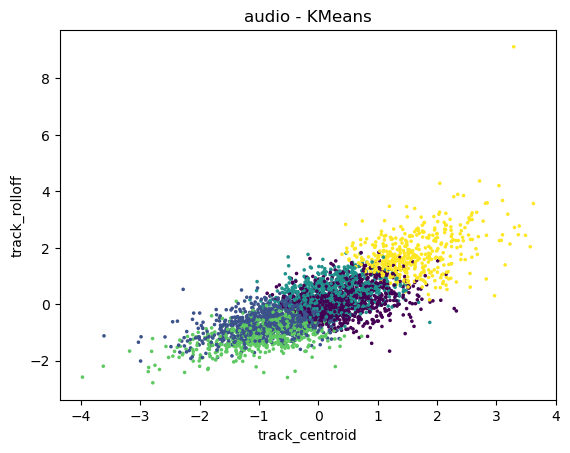

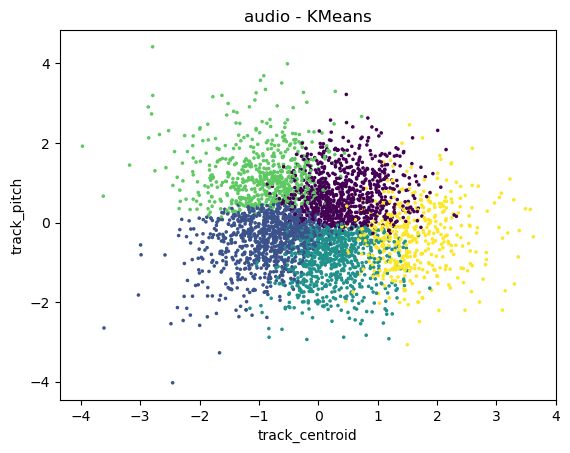

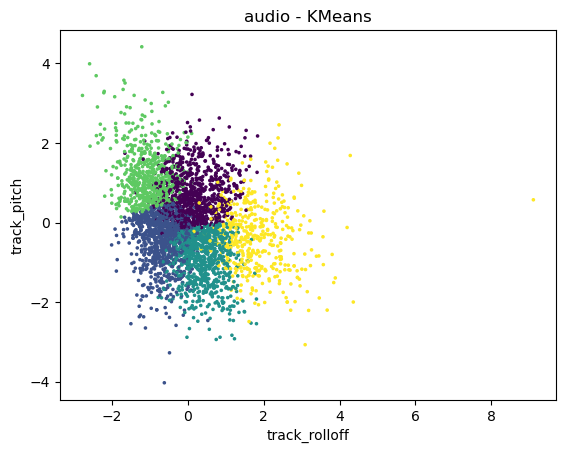

Clustering category: textual
Cluster data shape: (3776, 3)
Distinct entries count: 10
Unique values: [-1  0  1  2  3  4  5  6  7  8]
Counts per value: [3664   12   11   18   18   10    5   10   18   10]
Eps: 0.1
New best silhouette:  -0.3956807916933269
Separation:  1.4708259761228963
Distinct entries count: 12
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10]
Counts per value: [1952 1710   18   12   14    9   11   11   10   15   10    4]
Eps: 0.2
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 891 2885]
Eps: 0.3
Distinct entries count: 5
Unique values: [-1  0  1  2  3]
Counts per value: [ 507 3241   10   10    8]
Eps: 0.4
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 277 3499]
Eps: 0.5
New best silhouette:  0.48523796390794605
Separation:  2.116325628491241
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [ 187 3589]
Eps: 0.6
New best silhouette:  0.5232814642085857
Separation:  2.0571606030050265
Distinct entries count:

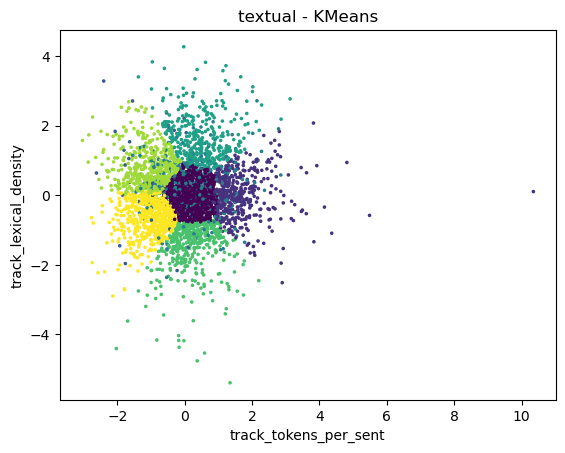

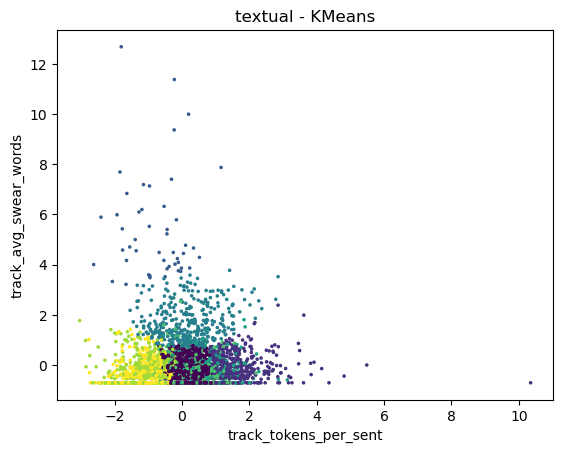

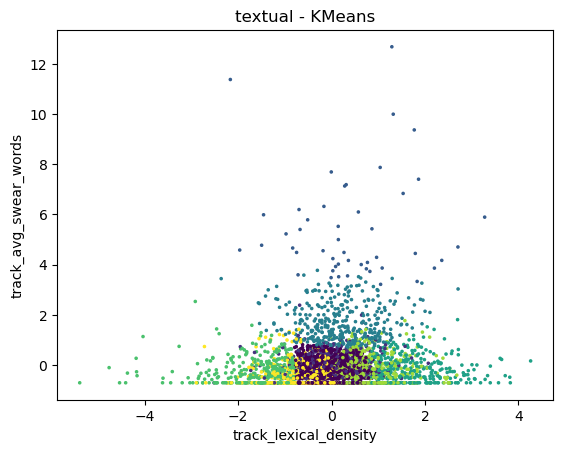

Clustering category: geo
Cluster data shape: (3776, 2)
Distinct entries count: 24
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Counts per value: [ 23 164  61 301 861 136  53 604 136  74 192  92 119 152  12  45  18  32
 158  89 128 106  67 153]
Eps: 0.1
Distinct entries count: 17
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Counts per value: [ 19 164 665 393 918 136 136  74 192 119 410  12  32 158 128  67 153]
Eps: 0.2
Distinct entries count: 14
Unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12]
Counts per value: [  5 164 665 603 918 209 192 418 119  12  32 158 128 153]
Eps: 0.3
Distinct entries count: 11
Unique values: [-1  0  1  2  3  4  5  6  7  8  9]
Counts per value: [   5  164  665  603 1545  192  247   12   32  158  153]
Eps: 0.4
Distinct entries count: 8
Unique values: [0 1 2 3 4 5 6 7]
Counts per value: [1741  665  603  197  247   12  158  153]
Eps: 0.5
New best silhouette:  0.7759879315103941
Separation

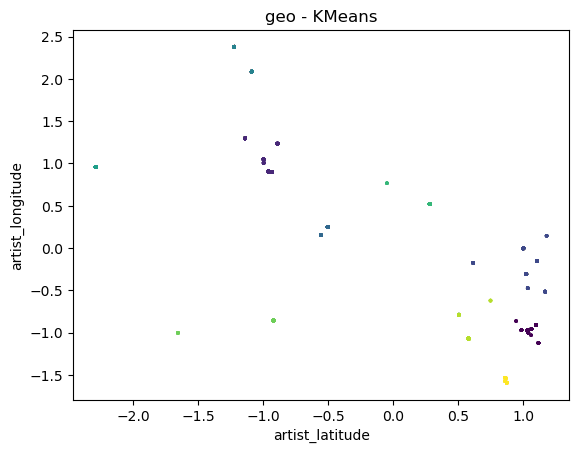

Clustering category: popularity
Cluster data shape: (3776, 2)
Distinct entries count: 7
Unique values: [-1  0  1  2  3  4  5]
Counts per value: [ 553 3141   28   12   15   10   17]
Eps: 0.1
New best silhouette:  0.0413572211299682
Separation:  1.4857008711962385
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 193 3575    8]
Eps: 0.2
New best silhouette:  0.3704315488384238
Separation:  1.7169398447746846
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [ 111 3654   11]
Eps: 0.3
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  70 3706]
Eps: 0.4
New best silhouette:  0.7094121834232218
Separation:  0.8331888518520463
Distinct entries count: 3
Unique values: [-1  0  1]
Counts per value: [  45 3722    9]
Eps: 0.5
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  26 3750]
Eps: 0.6
Distinct entries count: 2
Unique values: [-1  0]
Counts per value: [  15 3761]
Eps: 0.7
Distinct entries count: 2
Unique values

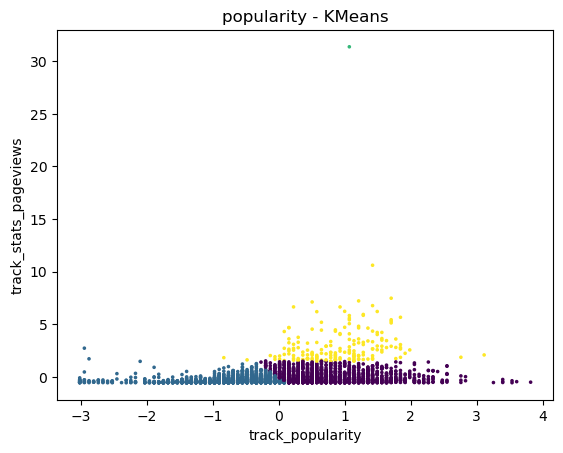

In [211]:
#cluster only coherent data

for category, cols in category_list.items():
    cluster_data = standardized[cols]
    print(f"Clustering category: {category}")

    best_n_clusters_kmeans, best_labels_kmeans = clusters_kmeans(cluster_data)
    
    best_n_clusters_dbscan, best_labels_dbscan = clusters_dbscan(cluster_data, eps_lims=[0.1, 3], iterations=30, verbose = True, min_noise = 0.01)
    
    plot_clusters(category_list=cols, dataset=standardized, fit_labels=best_labels_kmeans, label=f"{category} - KMeans")
    #plot_clusters(category_list=cols, dataset=standardized, fit_labels=best_labels_dbscan, label=f"{category} - DBSCAN")
    